Linear Regression Model

Train size: (1408, 11)
Test size : (289, 11)
MSE  : 13746328.81
RMSE : 3707.60
R²   : 0.3779


,Datum,Ist,Vorhersage
1408,2025-01-01,8678.4,23479.562484
1409,2025-01-02,7072.0,10974.886087
1410,2025-01-03,5737.6,6945.318004
1411,2025-01-04,12210.0,6453.748448
1412,2025-01-05,5389.9,8864.241740
1413,2025-01-06,5189.4,6956.357748
1414,2025-01-07,3482.0,16113.894684
1415,2025-01-08,3186.7,6002.200489
1416,2025-01-09,5361.6,5733.914889
1417,2025-01-10,7683.8,5122.657723


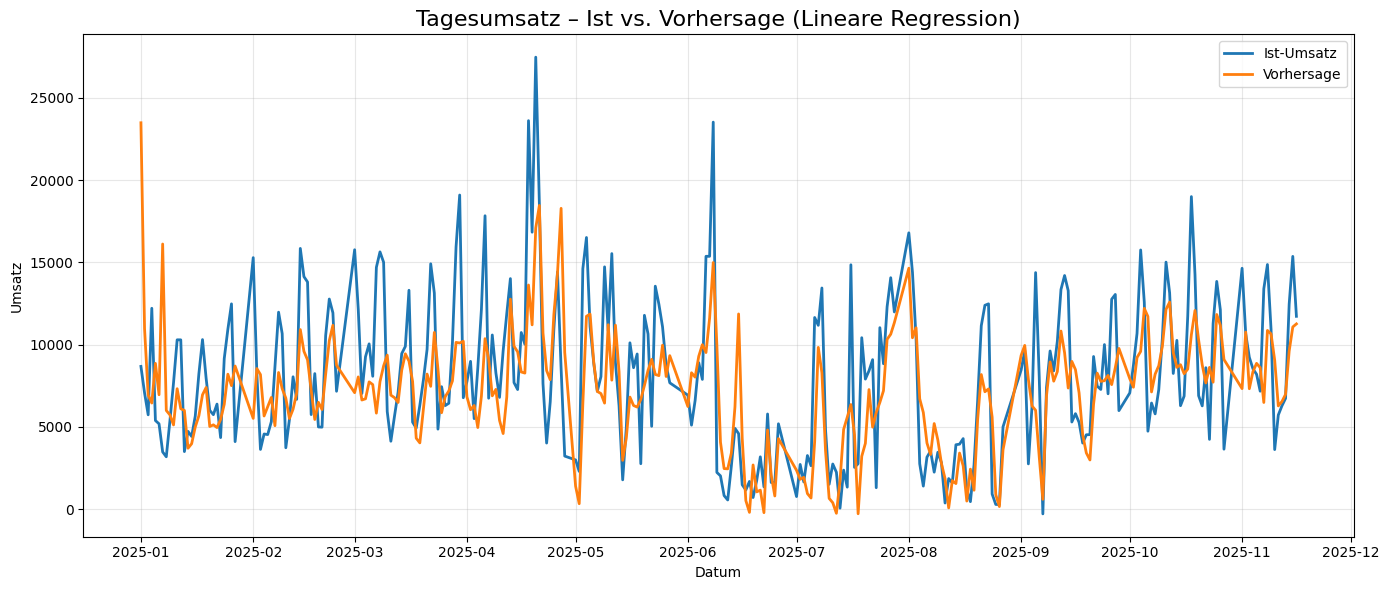

In [13]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 1) Daten laden
df = pd.read_csv("data/dataset-merged-2.csv")
# Datum konvertieren & sortieren
df["Datum"] = pd.to_datetime(df["Datum"])
df = df.sort_values("Datum")

# 2) Zielvariable definieren
target = "Restaurant"

# 3) Lag-Features
df["lag1"] = df[target].shift(1)
df["lag2"] = df[target].shift(2)
df["lag7"] = df[target].shift(7)
df["lag30"] = df[target].shift(30)

# Lags erzeugen NaN → entfernen
df = df.dropna().reset_index(drop=True)

# 4) Feature-Auswahl
num_cols = df.select_dtypes(include=["number"]).columns

feature_cols = [c for c in num_cols if c != target]

X = df[feature_cols]
y = df[target]

# 5) Zeitbasiertes Train/Test-Split
split_date = pd.Timestamp("2025-01-01")

train_mask = df["Datum"] < split_date
test_mask  = df["Datum"] >= split_date

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

# 6) Standardisierung
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7) Modell trainieren
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 8) Vorhersage & Evaluation
y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

# 9) Ergebnis-Tabelle
results = pd.DataFrame({
    "Datum": df.loc[test_mask, "Datum"],
    "Ist": y_test.values,
    "Vorhersage": y_pred
    })

display(results.head(15))


plt.figure(figsize=(14,6))
plt.plot(results["Datum"], results["Ist"], label="Ist-Umsatz", linewidth=2)
plt.plot(results["Datum"], results["Vorhersage"], label="Vorhersage", linewidth=2)

plt.title("Tagesumsatz – Ist vs. Vorhersage (Lineare Regression)", fontsize=16)
plt.xlabel("Datum")
plt.ylabel("Umsatz")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



Random Forest Model

ARIMA Model

LSTM Model

Prophet Model